## Conditional GAN for Fashion-MNIST Generation

This notebook implements a conditional GAN (cGAN) for generating Fashion-MNIST images conditioned on class labels. The architecture follows the standard cGAN approach where both generator and discriminator receive class information.

In [1]:
# %pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
batch_size = 128
z_dim = 100
num_classes = 10
img_size = 28
channels = 1
lr = 0.0002
betas = (0.5, 0.999)
num_epochs = 50

Using device: cuda


### Data Preparation

Load Fashion-MNIST dataset and create data loaders. Images are normalized to range [-1, 1] to match the generator's Tanh output.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", 
    train=True, 
    download=True, 
    transform=transform
)

# Create data loader
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True  # Drop last incomplete batch
)

# Class names for reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Dataset size: {len(train_dataset)} images")
print(f"Number of batches: {len(train_loader)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.83MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]

Dataset size: 60000 images
Number of batches: 468


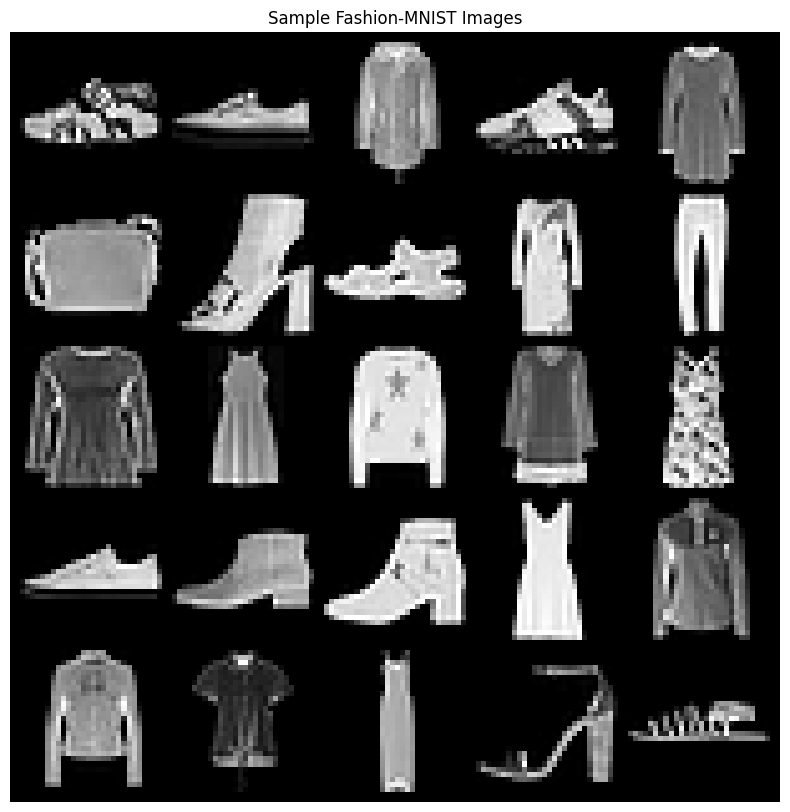

Labels for the first row: ['Sandal', 'Sneaker', 'Coat', 'Sneaker', 'Dress']


In [4]:
def show_sample_images():
    """Display a grid of sample images from the dataset"""
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    
    # Denormalize images
    images = images * 0.5 + 0.5
    
    # Create grid
    grid = make_grid(images[:25], nrow=5, normalize=False)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Sample Fashion-MNIST Images")
    plt.axis("off")
    plt.show()
    
    print("Labels for the first row:", [class_names[labels[i]] for i in range(5)])

show_sample_images()

### Model Architecture

#### Conditional Generator

The generator takes random noise and class labels as input. It uses:
- Embedding layer to convert labels to vectors
- Linear layer to project concatenated input
- Transposed convolutions for upsampling
- Tanh activation for output in range [-1, 1]

In [5]:
class Generator(nn.Module):
    """
    Conditional Generator for Fashion-MNIST.
    
    Args:
        z_dim: Dimension of random noise
        num_classes: Number of classes for conditioning
        img_size: Output image size (assumed square)
        channels: Number of image channels
    """
    def __init__(self, z_dim=100, num_classes=10, img_size=28, channels=1):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, z_dim)
        self.init_size = img_size // 4  # 7 for 28x28 images
        
        # Project and reshape
        self.l1 = nn.Sequential(
            nn.Linear(z_dim * 2, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(inplace=True),
        )
        
        # Convolutional upsampling layers
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),  # Output in range [-1, 1]
        )
    
    def forward(self, z, labels):
        """
        Forward pass of generator.
        
        Args:
            z: Random noise tensor (batch_size, z_dim)
            labels: Class labels (batch_size)
        
        Returns:
            Generated images (batch_size, channels, img_size, img_size)
        """
        # Get label embeddings and concatenate with noise
        label_emb = self.label_emb(labels)
        gen_input = torch.cat((z, label_emb), dim=1)
        
        # Project and reshape
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        
        # Generate images
        return self.conv_blocks(out)

#### Conditional Discriminator

The discriminator receives images and class labels. Conditioning is implemented by:
- Embedding labels and expanding to image size
- Concatenating label map as an additional channel
- Using convolutional layers for feature extraction
- Outputting a single logit for real/fake classification

In [6]:
class Discriminator(nn.Module):
    """
    Conditional Discriminator for Fashion-MNIST.
    
    Args:
        img_size: Input image size
        channels: Number of image channels
        num_classes: Number of classes for conditioning
    """
    def __init__(self, img_size=28, channels=1, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 1)
        self.img_size = img_size
        
        # Convolutional feature extractor
        self.model = nn.Sequential(
            # Input: (channels + 1) x 28 x 28
            nn.Conv2d(channels + 1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 64 x 14 x 14
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 128 x 7 x 7
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
            # Output: 1 (logit)
        )
    
    def forward(self, img, labels):
        """
        Forward pass of discriminator.
        
        Args:
            img: Input images (batch_size, channels, img_size, img_size)
            labels: Class labels (batch_size)
        
        Returns:
            Validity logits (batch_size, 1)
        """
        # Create label map
        label_input = self.label_emb(labels).view(-1, 1, 1, 1)
        label_input = label_input.expand(-1, 1, self.img_size, self.img_size)
        
        # Concatenate image with label map
        x = torch.cat((img, label_input), dim=1)
        
        return self.model(x)

In [7]:
G = Generator(z_dim, num_classes, img_size, channels).to(device)
D = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

criterion = nn.BCEWithLogitsLoss()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nGenerator parameters: {count_parameters(G):,}")
print(f"Discriminator parameters: {count_parameters(D):,}")


Generator parameters: 1,406,505
Discriminator parameters: 139,851


### Training Loop

The training follows the standard GAN procedure:
1. Train discriminator on real and fake images
2. Train generator to fool the discriminator
3. Visualize progress every 5 epochs

#### Training Details:
- **Discriminator**: Minimizes BCE loss for real (label=1) and fake (label=0) images
- **Generator**: Minimizes BCE loss for fake images with target label=1 (fool discriminator)
- Both networks are trained alternately in each batch

In [8]:
def visualize_results(G, epoch, device):
    """Generate and display samples from the generator."""
    G.eval()
    with torch.no_grad():
        # Generate one sample per class
        z = torch.randn(num_classes, z_dim, device=device)
        sample_labels = torch.arange(num_classes, device=device)
        fake_imgs = G(z, sample_labels)
        
        # Denormalize images
        fake_imgs = fake_imgs * 0.5 + 0.5
        
        # Create grid
        grid = make_grid(fake_imgs, nrow=5, normalize=False)
        
        plt.figure(figsize=(12, 4))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.title(f"Epoch {epoch+1} — One sample per class\n" + 
                 f"Classes: {', '.join(class_names[:5])} | {', '.join(class_names[5:])}")
        plt.axis("off")
        plt.show()
    G.train()

def plot_losses(g_losses, d_losses):
    """Plot training losses."""
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label='Generator Loss', alpha=0.7)
    plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [9]:
def train_gan(G, D, train_loader, num_epochs, device, save_interval=5):
    """
    Train the conditional GAN.
    
    Args:
        G: Generator model
        D: Discriminator model
        train_loader: DataLoader with training data
        num_epochs: Number of training epochs
        device: Device to train on
        save_interval: How often to visualize results
    """
    G.train()
    D.train()
    
    g_losses = []
    d_losses = []
    
    for epoch in range(num_epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        epoch_g_loss = 0
        epoch_d_loss = 0
        
        for i, (real_imgs, labels) in enumerate(pbar):
            real_imgs = real_imgs.to(device)
            labels = labels.to(device)
            current_batch_size = real_imgs.size(0)
            
            # train Discriminator
            optimizer_D.zero_grad()
            
            # Loss on real images
            real_validity = D(real_imgs, labels)
            real_loss = criterion(real_validity, torch.ones(current_batch_size, 1, device=device))
            
            # Loss on fake images
            z = torch.randn(current_batch_size, z_dim, device=device)
            fake_imgs = G(z, labels)
            fake_validity = D(fake_imgs.detach(), labels)
            fake_loss = criterion(fake_validity, torch.zeros(current_batch_size, 1, device=device))
            
            # Total discriminator loss
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()
            
            # train Generator
            optimizer_G.zero_grad()
            
            # Generate new fake images
            z = torch.randn(current_batch_size, z_dim, device=device)
            fake_imgs = G(z, labels)
            
            # Loss: try to fool discriminator
            fake_validity = D(fake_imgs, labels)
            g_loss = criterion(fake_validity, torch.ones(current_batch_size, 1, device=device))
            g_loss.backward()
            optimizer_G.step()
            
            # Accumulate losses
            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            
            # Update progress bar
            pbar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })
        
        # Average losses for the epoch
        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        # Visualize results
        if (epoch + 1) % save_interval == 0 or epoch == 0:
            visualize_results(G, epoch, device)
            # plot_losses(g_losses, d_losses)
    
    return g_losses, d_losses

### Start Training

Run the training loop and monitor progress.

Starting training...


Epoch 1/50: 100%|██████████| 468/468 [00:16<00:00, 28.51it/s, D_loss=0.5522, G_loss=0.8329]


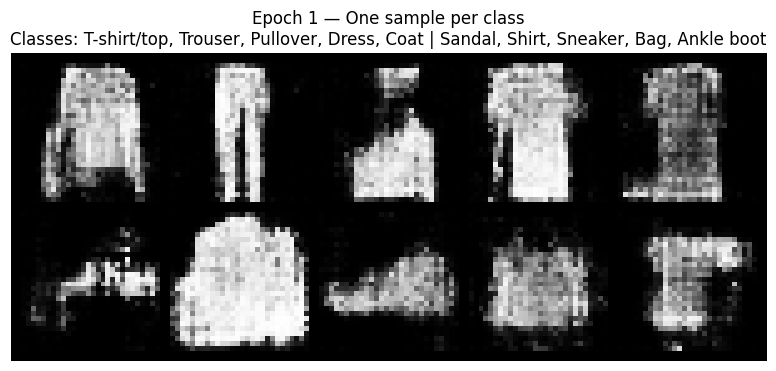

Epoch 5/50: 100%|██████████| 468/468 [00:15<00:00, 31.00it/s, D_loss=0.3614, G_loss=1.6987]


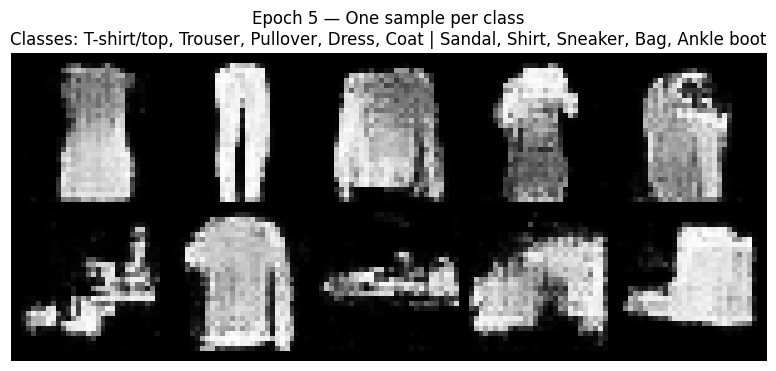

Epoch 10/50: 100%|██████████| 468/468 [00:15<00:00, 31.01it/s, D_loss=0.4666, G_loss=0.9285]


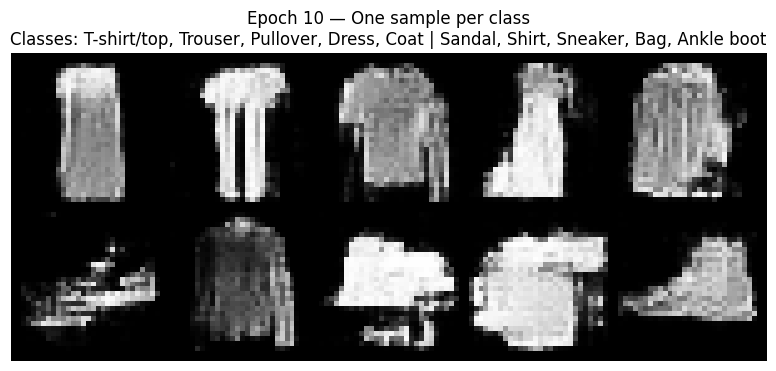

Epoch 15/50: 100%|██████████| 468/468 [00:15<00:00, 30.97it/s, D_loss=0.3643, G_loss=2.7050]


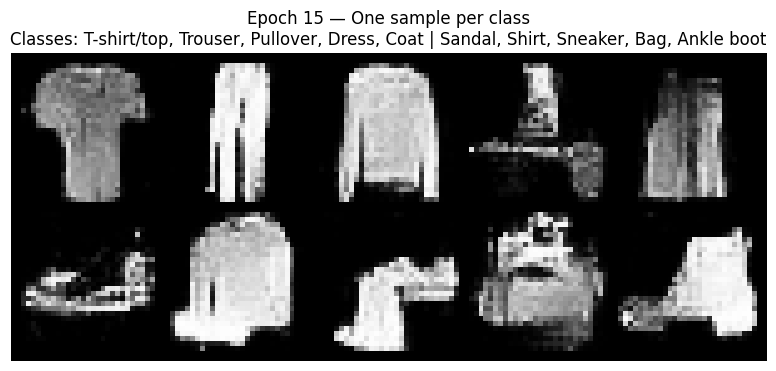

Epoch 20/50: 100%|██████████| 468/468 [00:15<00:00, 30.83it/s, D_loss=0.3397, G_loss=1.3821]


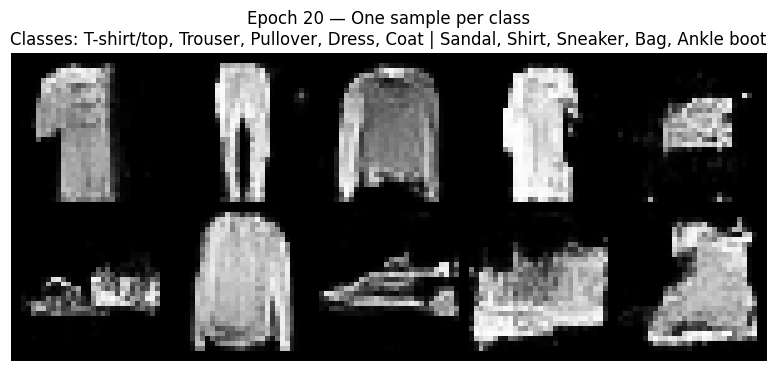

Epoch 25/50: 100%|██████████| 468/468 [00:15<00:00, 31.06it/s, D_loss=0.2365, G_loss=2.0219]


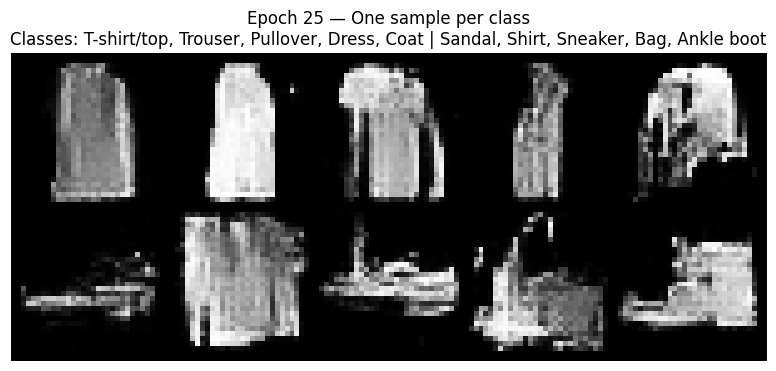

Epoch 30/50: 100%|██████████| 468/468 [00:15<00:00, 31.03it/s, D_loss=0.3028, G_loss=1.6604]


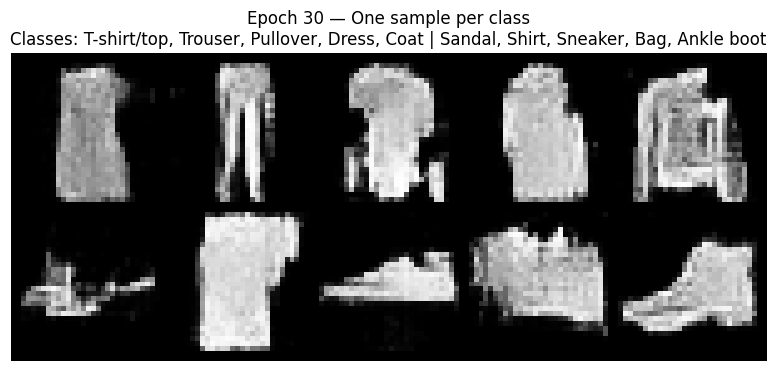

Epoch 35/50: 100%|██████████| 468/468 [00:15<00:00, 30.43it/s, D_loss=0.1738, G_loss=2.3069]


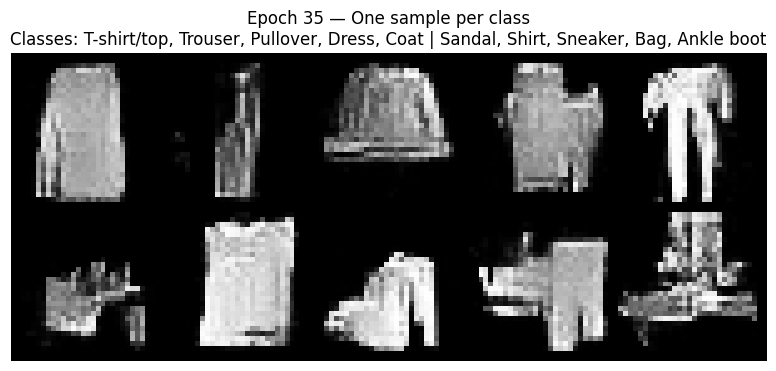

Epoch 40/50: 100%|██████████| 468/468 [00:15<00:00, 30.88it/s, D_loss=0.5088, G_loss=1.3786]


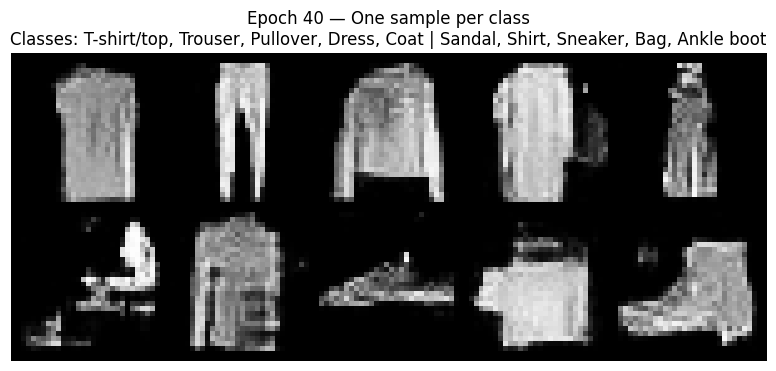

Epoch 45/50: 100%|██████████| 468/468 [00:15<00:00, 31.01it/s, D_loss=0.1343, G_loss=2.6533]


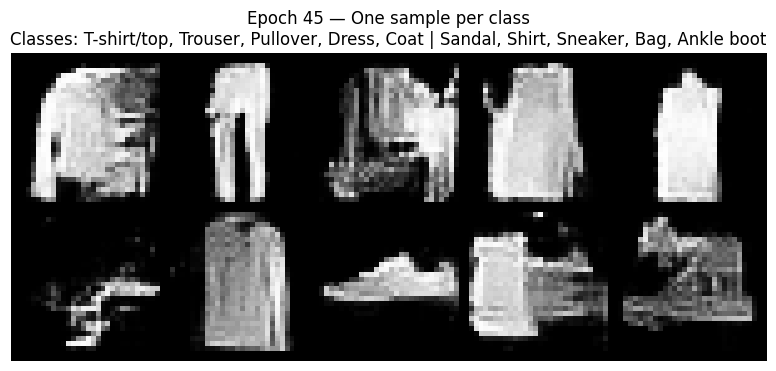

Epoch 50/50: 100%|██████████| 468/468 [00:15<00:00, 31.02it/s, D_loss=0.2951, G_loss=1.9663]


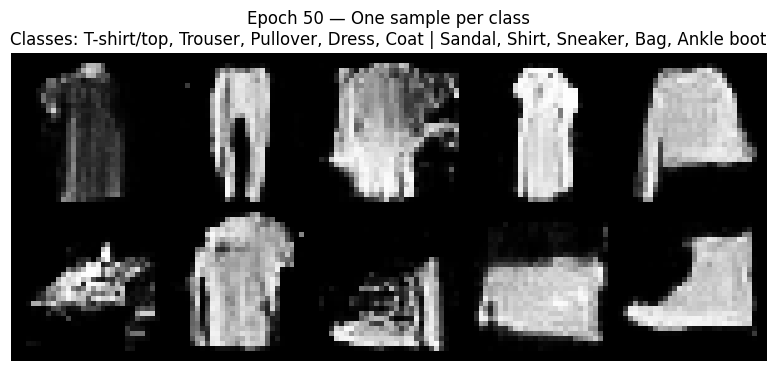

Training finished!


In [10]:
print("Starting training...")

g_losses, d_losses = train_gan(
    G=G,
    D=D,
    train_loader=train_loader,
    num_epochs=num_epochs,
    device=device,
    save_interval=5
)

print("Training finished!")

### Evaluation and Generation

Generate samples from specific classes to evaluate the trained model.

Generated samples for different clothing categories:


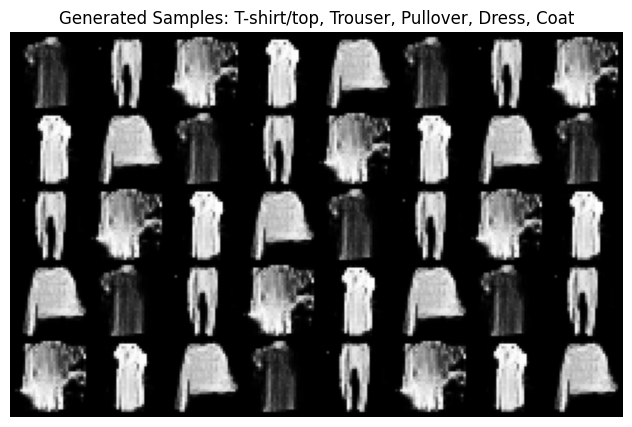

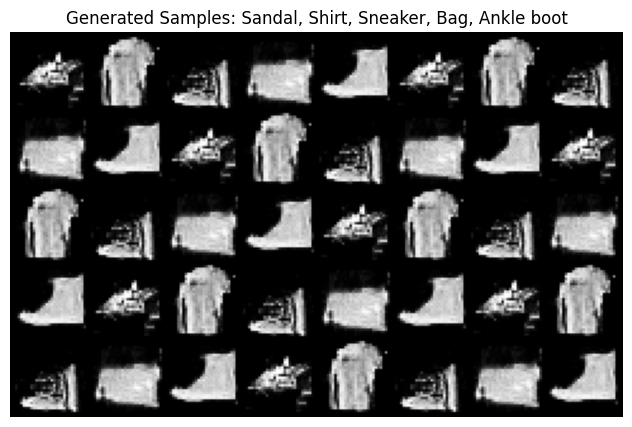

In [11]:
def generate_class_samples(G, class_indices, num_samples_per_class=8):
    """
    Generate samples for specific classes.
    
    Args:
        G: Trained generator
        class_indices: List of class indices to generate
        num_samples_per_class: Number of samples per class
    """
    G.eval()
    with torch.no_grad():
        total_samples = len(class_indices) * num_samples_per_class
        z = torch.randn(total_samples, z_dim, device=device)
        
        # Repeat class indices for each sample
        labels = torch.tensor(class_indices * num_samples_per_class, device=device)
        
        fake_imgs = G(z, labels)
        fake_imgs = fake_imgs * 0.5 + 0.5
        
        grid = make_grid(fake_imgs, nrow=num_samples_per_class, normalize=False)
        
        plt.figure(figsize=(15, 5))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        
        title = "Generated Samples: "
        for idx in class_indices:
            title += f"{class_names[idx]}, "
        plt.title(title[:-2])
        plt.axis("off")
        plt.show()
    
    G.train()

print("Generated samples for different clothing categories:")
generate_class_samples(G, [0, 1, 2, 3, 4])  # Tops and coats
generate_class_samples(G, [5, 6, 7, 8, 9])  # Shoes and bags

Multiple samples of Sneakers (class 7):


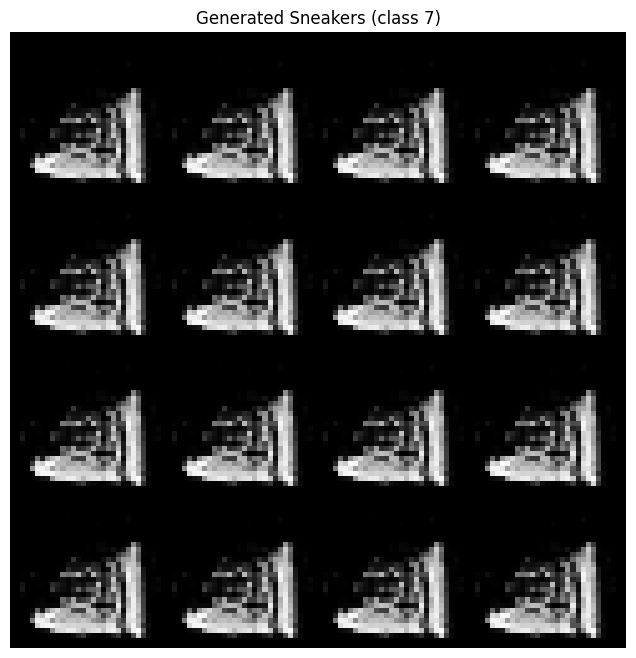

Generator(
  (label_emb): Embedding(10, 100)
  (l1): Sequential(
    (0): Linear(in_features=200, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)

In [12]:
# Generate multiple samples of sneakers (class 7)
print("Multiple samples of Sneakers (class 7):")
G.eval()
with torch.no_grad():
    z = torch.randn(16, z_dim, device=device)
    labels = torch.full((16,), 7, device=device, dtype=torch.long)  # Class 7: Sneaker
    
    fake = G(z, labels)
    fake = fake * 0.5 + 0.5
    
    grid = make_grid(fake, nrow=4, normalize=False)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.title("Generated Sneakers (class 7)")
    plt.axis("off")
    plt.show()
G.train()

### Model Analysis

#### Loss Curves
Plot the final training curves to analyze convergence.

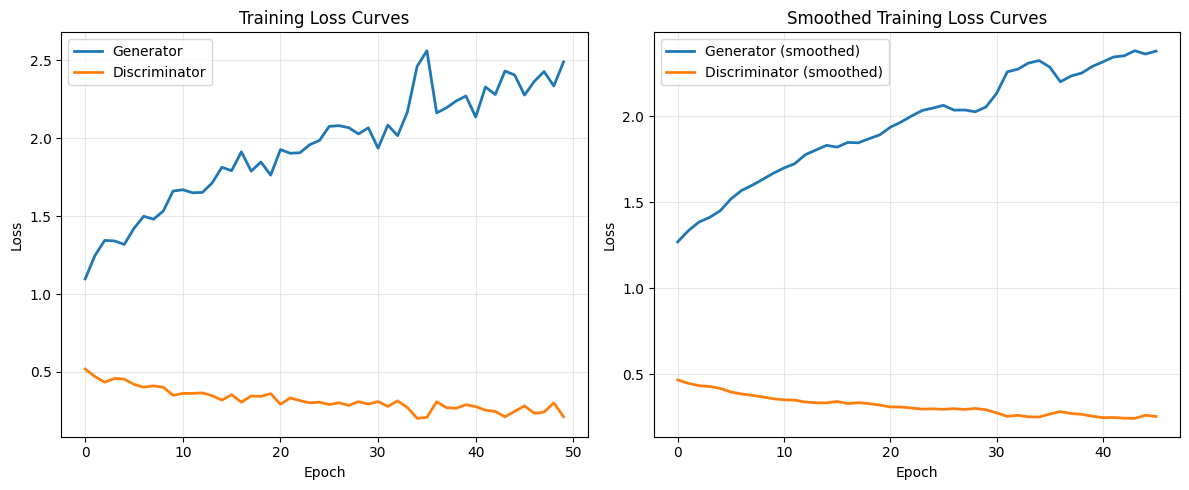

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(g_losses, label='Generator', linewidth=2)
plt.plot(d_losses, label='Discriminator', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
window_size = 5
smoothed_g = np.convolve(g_losses, np.ones(window_size)/window_size, mode='valid')
smoothed_d = np.convolve(d_losses, np.ones(window_size)/window_size, mode='valid')

plt.plot(smoothed_g, label='Generator (smoothed)', linewidth=2)
plt.plot(smoothed_d, label='Discriminator (smoothed)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Smoothed Training Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()